# SRNet Steganalysis - Local Training
**Classes:** BPCS | CLEAN | LSB | PVD

**Architecture:** SRNet (Boroumand et al., 2018) with SRM fixed preprocessing kernels

---

## Cell 1 — Install & Import Dependencies

In [5]:
# Install if not already installed
# !pip install seaborn

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

You should consider upgrading via the 'c:\users\naka\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip' command.


Using device: cuda
GPU: NVIDIA GeForce RTX 3070


## Cell 2 — Configuration

In [6]:
# ── EDIT PATHS HERE ──────────────────────────────────────────
BASE_DIR = Path(r'C:\Users\Naka\Downloads\stegano\DATASET_SPLIT-20260225T043041Z-1-001\DATASET_SPLIT')
CHECKPOINT_DIR = BASE_DIR.parent / 'checkpoints'
CHECKPOINT_DIR.mkdir(exist_ok=True)
BEST_MODEL_PATH = CHECKPOINT_DIR / 'srnet_best.pth'

# ── Hyperparameters ──────────────────────────────────────────
IMG_SIZE    = 256
BATCH_SIZE  = 16       # turunkan ke 8 kalau RAM/VRAM kurang
NUM_EPOCHS  = 200
LR          = 0.001
PATIENCE    = 20       # early stopping
NUM_CLASSES = 4
CLASSES     = ['BPCS', 'CLEAN', 'LSB', 'PVD']

print('Config OK')
print(f'  Dataset  : {BASE_DIR}')
print(f'  Checkpoint: {BEST_MODEL_PATH}')

Config OK
  Dataset  : C:\Users\Naka\Downloads\stegano\DATASET_SPLIT-20260225T043041Z-1-001\DATASET_SPLIT
  Checkpoint: C:\Users\Naka\Downloads\stegano\DATASET_SPLIT-20260225T043041Z-1-001\checkpoints\srnet_best.pth


## Cell 3 — DataLoader

In [7]:
# SRNet aslinya grayscale, tapi dataset bisa RGB.
# Kita pakai grayscale → 1 channel agar sesuai arsitektur SRNet.

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    # JANGAN pakai ColorJitter / Rotation — bisa merusak stego pattern
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

val_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

train_dataset = datasets.ImageFolder(BASE_DIR / 'train',      transform=train_transform)
val_dataset   = datasets.ImageFolder(BASE_DIR / 'validation', transform=val_test_transform)
test_dataset  = datasets.ImageFolder(BASE_DIR / 'test',       transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train : {len(train_dataset)} images, {len(train_loader)} batches')
print(f'Val   : {len(val_dataset)} images,   {len(val_loader)} batches')
print(f'Test  : {len(test_dataset)} images,  {len(test_loader)} batches')
print(f'Class map: {train_dataset.class_to_idx}')

Train : 2656 images, 166 batches
Val   : 570 images,   36 batches
Test  : 569 images,  36 batches
Class map: {'BPCS': 0, 'CLEAN': 1, 'LSB': 2, 'PVD': 3}


## Cell 4 — SRM Kernels (Fixed High-Pass Filters)

In [8]:
def get_srm_kernels():
    """
    30 SRM (Spatial Rich Model) high-pass filter kernels.
    Source: Fridrich & Kodovsky, IEEE TIFS 2012.
    Weights diset fixed (tidak ditraining).
    """
    # ── 5x5 kernels ──────────────────────────────────────────
    # Setiap kernel berukuran 5x5
    srm_kernels = np.zeros((30, 1, 5, 5), dtype=np.float32)

    # Kernel set 1: 1st order horizontal / vertical / diagonal
    # (edge detection residuals)
    k = 0
    
    # 1st order
    f = np.array([[0,0,0,0,0],[0,0,0,0,0],[0,0,-1,1,0],[0,0,0,0,0],[0,0,0,0,0]], dtype=np.float32)
    srm_kernels[k] = f; k+=1
    f = np.array([[0,0,0,0,0],[0,0,0,0,0],[0,1,-1,0,0],[0,0,0,0,0],[0,0,0,0,0]], dtype=np.float32)
    srm_kernels[k] = f; k+=1
    f = np.array([[0,0,0,0,0],[0,0,1,0,0],[0,0,-1,0,0],[0,0,0,0,0],[0,0,0,0,0]], dtype=np.float32)
    srm_kernels[k] = f; k+=1
    f = np.array([[0,0,0,0,0],[0,0,0,0,0],[0,0,-1,0,0],[0,0,1,0,0],[0,0,0,0,0]], dtype=np.float32)
    srm_kernels[k] = f; k+=1

    # 2nd order
    f = np.array([[0,0,0,0,0],[0,0,0,0,0],[0,1,-2,1,0],[0,0,0,0,0],[0,0,0,0,0]], dtype=np.float32) / 2
    srm_kernels[k] = f; k+=1
    f = np.array([[0,0,0,0,0],[0,0,1,0,0],[0,0,-2,0,0],[0,0,1,0,0],[0,0,0,0,0]], dtype=np.float32) / 2
    srm_kernels[k] = f; k+=1
    f = np.array([[0,0,0,0,0],[0,1,0,0,0],[0,0,-2,0,0],[0,0,0,1,0],[0,0,0,0,0]], dtype=np.float32) / 2
    srm_kernels[k] = f; k+=1
    f = np.array([[0,0,0,0,0],[0,0,0,1,0],[0,0,-2,0,0],[0,1,0,0,0],[0,0,0,0,0]], dtype=np.float32) / 2
    srm_kernels[k] = f; k+=1

    # 3rd order (horizontal)
    f = np.array([[0,0,0,0,0],[0,0,0,0,0],[0,-1,3,-3,1],[0,0,0,0,0],[0,0,0,0,0]], dtype=np.float32) / 3
    srm_kernels[k] = f; k+=1
    f = np.array([[0,0,0,0,0],[0,0,0,0,0],[1,-3,3,-1,0],[0,0,0,0,0],[0,0,0,0,0]], dtype=np.float32) / 3
    srm_kernels[k] = f; k+=1
    # 3rd order (vertical)
    f = np.array([[0,0,0,0,0],[0,0,-1,0,0],[0,0,3,0,0],[0,0,-3,0,0],[0,0,1,0,0]], dtype=np.float32) / 3
    srm_kernels[k] = f; k+=1
    f = np.array([[0,0,1,0,0],[0,0,-3,0,0],[0,0,3,0,0],[0,0,-1,0,0],[0,0,0,0,0]], dtype=np.float32) / 3
    srm_kernels[k] = f; k+=1

    # 2D Laplacian-like
    f = np.array([[0,0,0,0,0],[0,0,1,0,0],[0,1,-4,1,0],[0,0,1,0,0],[0,0,0,0,0]], dtype=np.float32) / 4
    srm_kernels[k] = f; k+=1

    # Square kernels (2D 2nd order)
    f = np.array([[0,0,0,0,0],[0,-1,2,-1,0],[0,2,-4,2,0],[0,-1,2,-1,0],[0,0,0,0,0]], dtype=np.float32) / 4
    srm_kernels[k] = f; k+=1

    # 3x3 SRM embedded in 5x5
    base_3x3_list = [
        np.array([[-1,2,-1],[2,-4,2],[-1,2,-1]], dtype=np.float32) / 4,
        np.array([[0,-1,0],[-1,4,-1],[0,-1,0]], dtype=np.float32) / 4,
        np.array([[-1,0,1],[0,0,0],[1,0,-1]], dtype=np.float32) / 2,
        np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float32) / 4,
        np.array([[1,-2,1],[-2,4,-2],[1,-2,1]], dtype=np.float32) / 4,
        np.array([[0,0,0],[1,-2,1],[0,0,0]], dtype=np.float32) / 2,
        np.array([[0,1,0],[0,-2,0],[0,1,0]], dtype=np.float32) / 2,
        np.array([[1,0,-1],[0,0,0],[-1,0,1]], dtype=np.float32) / 2,
        np.array([[-1,2,-2],[2,-4,2],[-1,2,-1]], dtype=np.float32) / 4,
        np.array([[2,-4,2],[-4,8,-4],[2,-4,2]], dtype=np.float32) / 8,
        np.array([[-1,2,-1],[0,0,0],[1,-2,1]], dtype=np.float32) / 2,
        np.array([[-1,0,1],[2,0,-2],[-1,0,1]], dtype=np.float32) / 2,
    ]
    for kern3 in base_3x3_list:
        if k >= 30:
            break
        f = np.zeros((5,5), dtype=np.float32)
        f[1:4, 1:4] = kern3
        srm_kernels[k] = f; k+=1

    # Fill remaining slots with rotations if needed
    while k < 30:
        base = srm_kernels[k % 14].copy()
        srm_kernels[k] = np.rot90(base, k % 4, axes=(1, 2))
        k += 1

    return torch.tensor(srm_kernels)

print(f'SRM kernels shape: {get_srm_kernels().shape}')  # (30, 1, 5, 5)

SRM kernels shape: torch.Size([30, 1, 5, 5])


## Cell 5 — SRNet Architecture

In [7]:
class SRMLayer(nn.Module):
    """Fixed SRM high-pass filter layer (tidak ditraining)"""
    def __init__(self):
        super().__init__()
        srm_weights = get_srm_kernels()  # (30, 1, 5, 5)
        self.register_buffer('weight', srm_weights)
        # Truncation activation (TLU) — clamp ke [-T, T]
        self.T = 3.0

    def forward(self, x):
        # x shape: (B, 1, H, W)
        out = nn.functional.conv2d(x, self.weight, padding=2)
        return out.clamp(-self.T, self.T)  # TLU activation


class Type1Block(nn.Module):
    """Residual block WITHOUT downsampling"""
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.block(x) + x)


class Type2Block(nn.Module):
    """Residual block WITH downsampling (AvgPool)"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.downsample = nn.Sequential(
            nn.AvgPool2d(3, stride=2, padding=1),
        )
        # Shortcut untuk menyamakan channel & spatial size
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.pool = nn.AvgPool2d(3, stride=2, padding=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.pool(self.shortcut(x))
        out = self.pool(self.block(x))
        return self.relu(out + residual)


class SRNet(nn.Module):
    """
    SRNet: Steganalysis Residual Network
    Boroumand et al., IEEE TIFS 2019
    
    Modified untuk multi-class (4 classes) steganalysis.
    """
    def __init__(self, num_classes=4):
        super().__init__()

        # Layer 0: Fixed SRM preprocessing
        self.srm = SRMLayer()  # output: (B, 30, H, W)

        # Layer 1: Conv to reduce to 64 channels
        self.layer1 = nn.Sequential(
            nn.Conv2d(30, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        # Type 1 Blocks (no downsampling)
        self.type1_blocks = nn.Sequential(
            Type1Block(64),
            Type1Block(64),
        )

        # Type 2 Blocks (with downsampling + channel expansion)
        self.type2_blocks = nn.Sequential(
            Type2Block(64,  128),  # 256 → 128
            Type2Block(128, 256),  # 128 → 64
            Type2Block(256, 512),  # 64  → 32
            Type2Block(512, 512),  # 32  → 16
            Type2Block(512, 512),  # 16  → 8
        )

        # Type 3: Global Average Pooling + Classifier
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.srm(x)          # Fixed SRM filter
        x = self.layer1(x)       # Initial conv
        x = self.type1_blocks(x) # Type 1
        x = self.type2_blocks(x) # Type 2 (downsampling)
        x = self.gap(x)          # Global avg pool
        x = self.classifier(x)   # FC → logits
        return x


# ── Sanity check ─────────────────────────────────────────────
model = SRNet(num_classes=NUM_CLASSES).to(DEVICE)
dummy = torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
out = model(dummy)
print(f'Model output shape: {out.shape}')  # expected: (2, 4)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable:,}')

Model output shape: torch.Size([2, 4])
Total params    : 14,957,316
Trainable params: 14,957,316


## Cell 6 — Training Setup

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adamax(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.2, patience=10, verbose=True
)

# ── History ──────────────────────────────────────────────────
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
}

print('Optimizer:', optimizer.__class__.__name__)
print('Scheduler: ReduceLROnPlateau')
print('Loss: CrossEntropyLoss')

Optimizer: Adamax
Scheduler: ReduceLROnPlateau
Loss: CrossEntropyLoss


c:\Users\Naka\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Cell 7 — Training Loop

In [9]:
def run_epoch(loader, model, criterion, optimizer=None, phase='train'):
    is_train = (phase == 'train')
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        pbar = tqdm(loader, desc=f'{phase.upper():>5}', leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            preds = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            total_loss += loss.item() * labels.size(0)

            pbar.set_postfix(loss=f'{loss.item():.4f}')

    return total_loss / total, correct / total


# ── Main Training Loop ────────────────────────────────────────
best_val_loss = float('inf')
patience_counter = 0

print(f'Starting training for up to {NUM_EPOCHS} epochs...')
print(f'Early stopping patience: {PATIENCE}')
print('-' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer, 'train')
    val_loss,   val_acc   = run_epoch(val_loader,   model, criterion, None,      'val')

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch:03d}/{NUM_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}', end='')

    # ── Save best model ───────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, BEST_MODEL_PATH)
        print(' ← Best saved ✓')
    else:
        patience_counter += 1
        print(f' (patience {patience_counter}/{PATIENCE})')

    # ── Early stopping ────────────────────────────────────────
    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}!')
        break

print('\nTraining complete!')
print(f'Best Val Loss: {best_val_loss:.4f}')

Starting training for up to 200 epochs...
Early stopping patience: 20
-----------------------------------------------------------------


Epoch [001/200] Train Loss: 1.1719 Acc: 0.4559 | Val Loss: 1.2056 Acc: 0.4807 ← Best saved ✓


Epoch [002/200] Train Loss: 0.9083 Acc: 0.5681 | Val Loss: 1.1084 Acc: 0.5456 ← Best saved ✓


Epoch [003/200] Train Loss: 0.8391 Acc: 0.6088 | Val Loss: 0.7837 Acc: 0.6316 ← Best saved ✓


Epoch [004/200] Train Loss: 0.8112 Acc: 0.6152 | Val Loss: 0.7864 Acc: 0.6754 (patience 1/20)


...

Epoch [019/200] Train Loss: 0.1395 Acc: 0.9473 | Val Loss: 6.6318 Acc: 0.7439 (patience 1/20)


Epoch [020/200] Train Loss: 0.0983 Acc: 0.9650 | Val Loss: 0.0440 Acc: 0.9877 ← Best saved ✓


Epoch [021/200] Train Loss: 0.1109 Acc: 0.9586 | Val Loss: 0.0427 Acc: 0.9895 ← Best saved ✓


Epoch [022/200] Train Loss: 0.0722 Acc: 0.9804 | Val Loss: 0.0383 Acc: 0.9912 ← Best saved ✓


KeyboardInterrupt: 

## Cell 8 — Training Curves

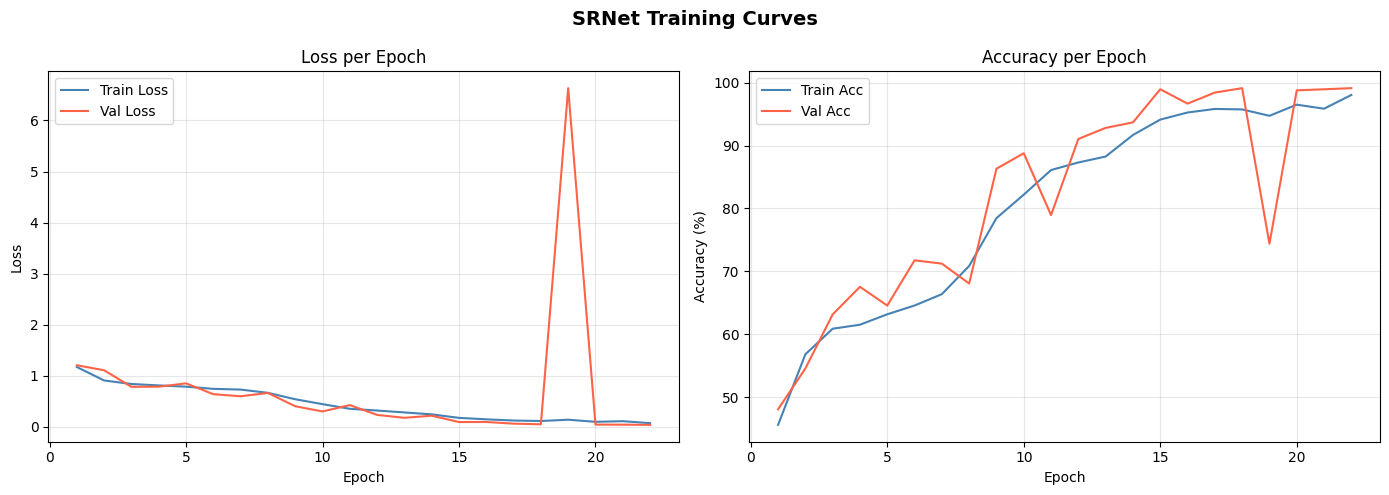

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='steelblue')
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato')
ax1.set_title('Loss per Epoch'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in history['train_acc']], label='Train Acc', color='steelblue')
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val Acc',   color='tomato')
ax2.set_title('Accuracy per Epoch'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('SRNet Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 9 — Evaluation on Test Set

In [11]:
# Load best model
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"(val_loss={checkpoint['val_loss']:.4f}, val_acc={checkpoint['val_acc']:.4f})")

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Testing'):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Classification Report ─────────────────────────────────────
print('\n' + '='*55)
print('CLASSIFICATION REPORT')
print('='*55)
print(classification_report(all_labels, all_preds, target_names=CLASSES))

overall_acc = (all_preds == all_labels).mean() * 100
print(f'Overall Test Accuracy: {overall_acc:.2f}%')

Loaded best model from epoch 22 (val_loss=0.0383, val_acc=0.9912)


Testing: 100%|██████████| 36/36 [01:39<00:00,  2.76s/it]


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        BPCS       0.99      0.96      0.97       144
       CLEAN       0.97      0.99      0.98       144
         LSB       0.97      1.00      0.99       144
         PVD       1.00      0.99      0.99       137

    accuracy                           0.98       569
   macro avg       0.98      0.98      0.98       569
weighted avg       0.98      0.98      0.98       569

Overall Test Accuracy: 98.24%


## Cell 10 — Confusion Matrix

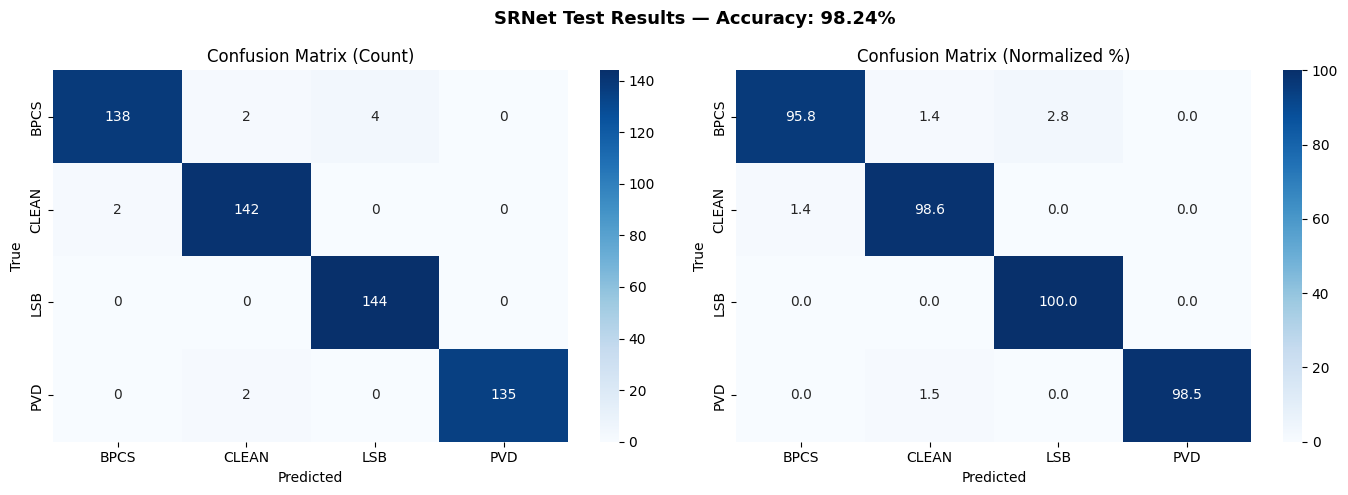

In [12]:
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# Normalized (%)
sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized %)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle(f'SRNet Test Results — Accuracy: {overall_acc:.2f}%', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 11 — Visualize Sample Predictions

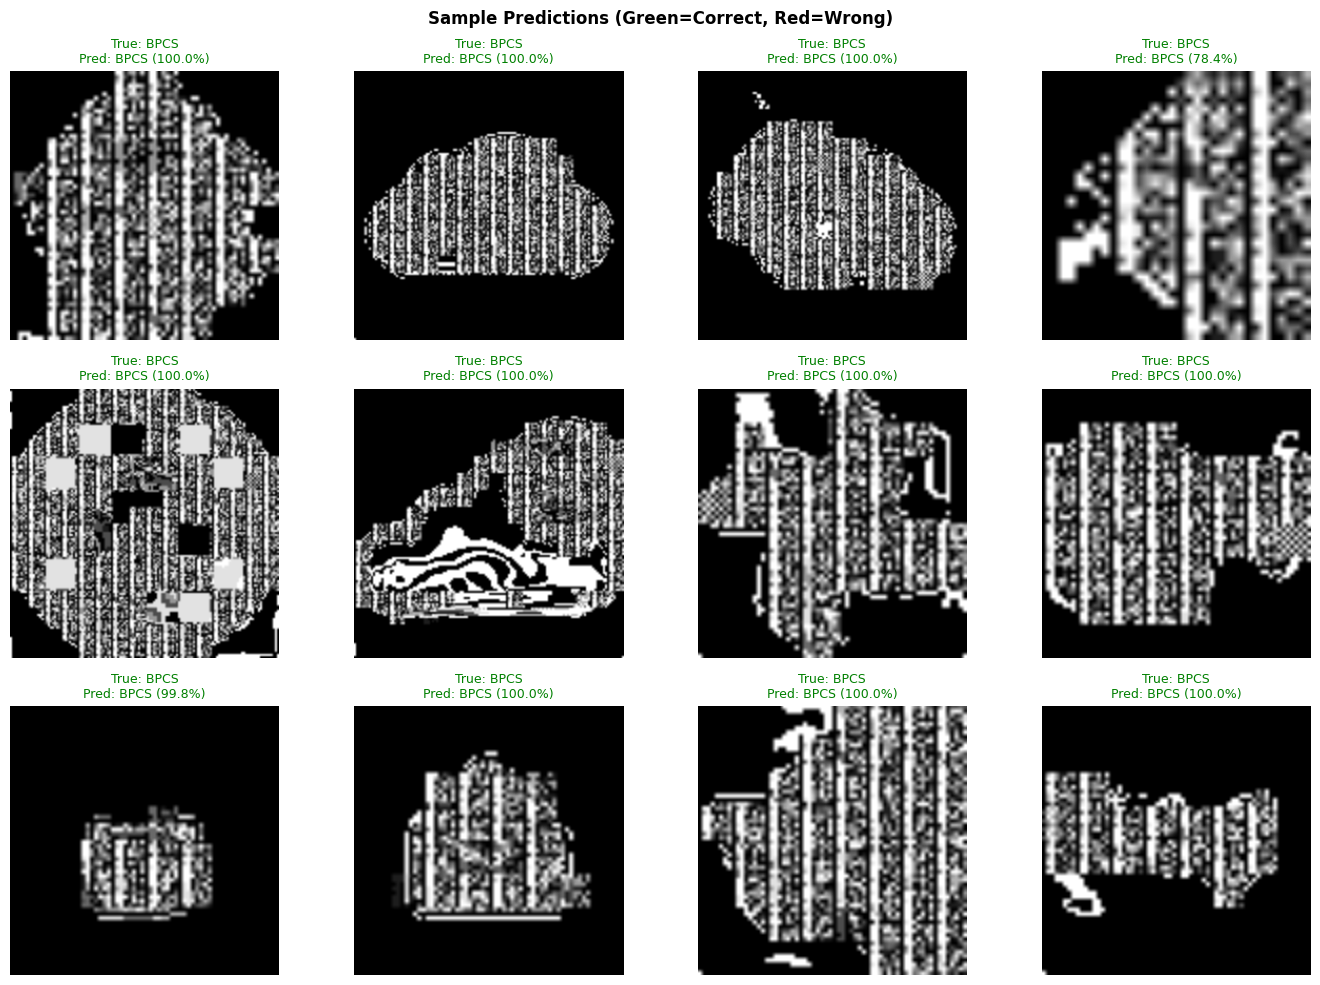

In [15]:
def denormalize(tensor):
    return tensor * 0.5 + 0.5

model.eval()
imgs_batch, labels_batch = next(iter(test_loader))
imgs_batch = imgs_batch.to(DEVICE)

with torch.no_grad():
    outputs = model(imgs_batch)
    probs = torch.softmax(outputs, dim=1).cpu()
    preds = outputs.argmax(dim=1).cpu()

n_show = min(12, len(imgs_batch))
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i in range(n_show):
    img = denormalize(imgs_batch[i].cpu()).squeeze().numpy()
    true_label = CLASSES[labels_batch[i].item()]
    pred_label = CLASSES[preds[i].item()]
    conf = probs[i].max().item() * 100

    axes[i].imshow(img, cmap='gray')
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(
        f'True: {true_label}\nPred: {pred_label} ({conf:.1f}%)',
        color=color, fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — Save Full Training Summary

In [14]:
summary = {
    'best_epoch': checkpoint['epoch'],
    'best_val_loss': checkpoint['val_loss'],
    'best_val_acc': checkpoint['val_acc'],
    'test_accuracy': overall_acc,
    'history': history,
    'class_map': train_dataset.class_to_idx,
}

import json
summary_path = CHECKPOINT_DIR / 'training_summary.json'
# Convert numpy to python native for JSON serialization
summary_json = {
    'best_epoch': int(summary['best_epoch']),
    'best_val_loss': float(summary['best_val_loss']),
    'best_val_acc': float(summary['best_val_acc']),
    'test_accuracy': float(summary['test_accuracy']),
    'class_map': summary['class_map'],
    'config': {
        'img_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'lr': LR,
        'num_epochs': NUM_EPOCHS,
        'seed': SEED,
    }
}
with open(summary_path, 'w') as f:
    json.dump(summary_json, f, indent=2)

print('All outputs saved to:', CHECKPOINT_DIR)
print('  srnet_best.pth        — Model checkpoint')
print('  training_curves.png   — Loss & Accuracy curves')
print('  confusion_matrix.png  — Confusion matrix')
print('  sample_predictions.png — Visual predictions')
print('  training_summary.json — Summary stats')
print(f'\nFinal Test Accuracy: {overall_acc:.2f}%')

All outputs saved to: C:\Users\Naka\Downloads\stegano\DATASET_SPLIT-20260225T043041Z-1-001\checkpoints
  srnet_best.pth        — Model checkpoint
  training_curves.png   — Loss & Accuracy curves
  confusion_matrix.png  — Confusion matrix
  sample_predictions.png — Visual predictions
  training_summary.json — Summary stats

Final Test Accuracy: 98.24%


Testing pemakaian

In [11]:
class SRMLayer(nn.Module):
    """Fixed SRM high-pass filter layer (tidak ditraining)"""
    def __init__(self):
        super().__init__()
        srm_weights = get_srm_kernels()  # (30, 1, 5, 5)
        self.register_buffer('weight', srm_weights)
        # Truncation activation (TLU) — clamp ke [-T, T]
        self.T = 3.0

    def forward(self, x):
        # x shape: (B, 1, H, W)
        out = nn.functional.conv2d(x, self.weight, padding=2)
        return out.clamp(-self.T, self.T)  # TLU activation


class Type1Block(nn.Module):
    """Residual block WITHOUT downsampling"""
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.block(x) + x)


class Type2Block(nn.Module):
    """Residual block WITH downsampling (AvgPool)"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.downsample = nn.Sequential(
            nn.AvgPool2d(3, stride=2, padding=1),
        )
        # Shortcut untuk menyamakan channel & spatial size
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.pool = nn.AvgPool2d(3, stride=2, padding=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.pool(self.shortcut(x))
        out = self.pool(self.block(x))
        return self.relu(out + residual)


class SRNet(nn.Module):
    """
    SRNet: Steganalysis Residual Network
    Boroumand et al., IEEE TIFS 2019
    
    Modified untuk multi-class (4 classes) steganalysis.
    """
    def __init__(self, num_classes=4):
        super().__init__()

        # Layer 0: Fixed SRM preprocessing
        self.srm = SRMLayer()  # output: (B, 30, H, W)

        # Layer 1: Conv to reduce to 64 channels
        self.layer1 = nn.Sequential(
            nn.Conv2d(30, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        # Type 1 Blocks (no downsampling)
        self.type1_blocks = nn.Sequential(
            Type1Block(64),
            Type1Block(64),
        )

        # Type 2 Blocks (with downsampling + channel expansion)
        self.type2_blocks = nn.Sequential(
            Type2Block(64,  128),  # 256 → 128
            Type2Block(128, 256),  # 128 → 64
            Type2Block(256, 512),  # 64  → 32
            Type2Block(512, 512),  # 32  → 16
            Type2Block(512, 512),  # 16  → 8
        )

        # Type 3: Global Average Pooling + Classifier
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.srm(x)          # Fixed SRM filter
        x = self.layer1(x)       # Initial conv
        x = self.type1_blocks(x) # Type 1
        x = self.type2_blocks(x) # Type 2 (downsampling)
        x = self.gap(x)          # Global avg pool
        x = self.classifier(x)   # FC → logits
        return x

In [12]:
# load model dari file terbaik
def load_best_model(path: Path = BEST_MODEL_PATH,
					device: torch.device = DEVICE):
	"""
	kembalikan model SRNet dan dictionary checkpoint yang di‑load
	"""
	# buat ulang arsitektur sama seperti saat training
	mdl = SRNet(num_classes=NUM_CLASSES).to(device)
	ckpt = torch.load(path, map_location=device)
	mdl.load_state_dict(ckpt['model_state_dict'])
	mdl.eval()
	print(f"Loaded model from epoch {ckpt['epoch']} "
		  f"(val_loss={ckpt['val_loss']:.4f}, val_acc={ckpt['val_acc']:.4f})")
	return mdl, ckpt

# contoh pemakaian
model, checkpoint = load_best_model()

Loaded model from epoch 22 (val_loss=0.0383, val_acc=0.9912)


In [ ]:
from PIL import Image
import torch

# Pastikan CLASSES sesuai dengan urutan index model (misal: ['BPCS', 'CLEAN', 'LSB', 'PVD'])
# image_paths tetap sama seperti sebelumnya
image_paths = [
    # BASE_DIR / 'test' / 'LSB'   / 'full-color_0907.png',
    # BASE_DIR / 'test' / 'CLEAN' / 'CLEAN_00054.png',
    # BASE_DIR / 'test' / 'BPCS'  / 'pokemon_99.png',
    # BASE_DIR / 'test' / 'PVD'   / 'pokemon_56.png',
    "C:\\Users\\Naka\\Downloads\\stegano\\DATASET_SPLIT-20260225T043041Z-1-001\\checkpoints\\test\\hasil_stego.png",
    "C:\\Users\\Naka\\Downloads\\stegano\\DATASET_SPLIT-20260225T043041Z-1-001\\checkpoints\\test\\test.png",
]

imgs = []
for p in image_paths:
    img = Image.open(p).convert('RGB')
    img = val_test_transform(img)
    imgs.append(img)
    
imgs_tensor = torch.stack(imgs).to(DEVICE)

model.eval()
with torch.no_grad():
    outputs = model(imgs_tensor)
    probs   = torch.softmax(outputs, dim=1)
    preds   = outputs.argmax(dim=1)

# --- BAGIAN MODIFIKASI TAMPILAN ---
print(f"{'File Name':30} |  {'Predicted':8} | {'Confidence'}")
print("-" * 70)

for p, idx, prob in zip(image_paths, preds.cpu().numpy(), probs.cpu().numpy()):
    # expected = p.parent.name  # Mengambil nama folder (LSB, CLEAN, dll)
    predicted = CLASSES[idx]
    confidence = prob[idx] * 100
    
    # Tambahkan indikator biar enak dilihat (Checkmark jika benar)
    # status = "✅" if expected.upper() == predicted.upper() else "❌"

    print(f"{str(p):30} | {predicted:8} | {confidence:.1f}%")

File Name                      |  Predicted | Confidence
----------------------------------------------------------------------
C:\Users\Naka\Downloads\stegano\DATASET_SPLIT-20260225T043041Z-1-001\checkpoints\test\hasil_stego.png | CLEAN    | 62.6%
C:\Users\Naka\Downloads\stegano\DATASET_SPLIT-20260225T043041Z-1-001\checkpoints\test\test-image.png | CLEAN    | 61.8%
